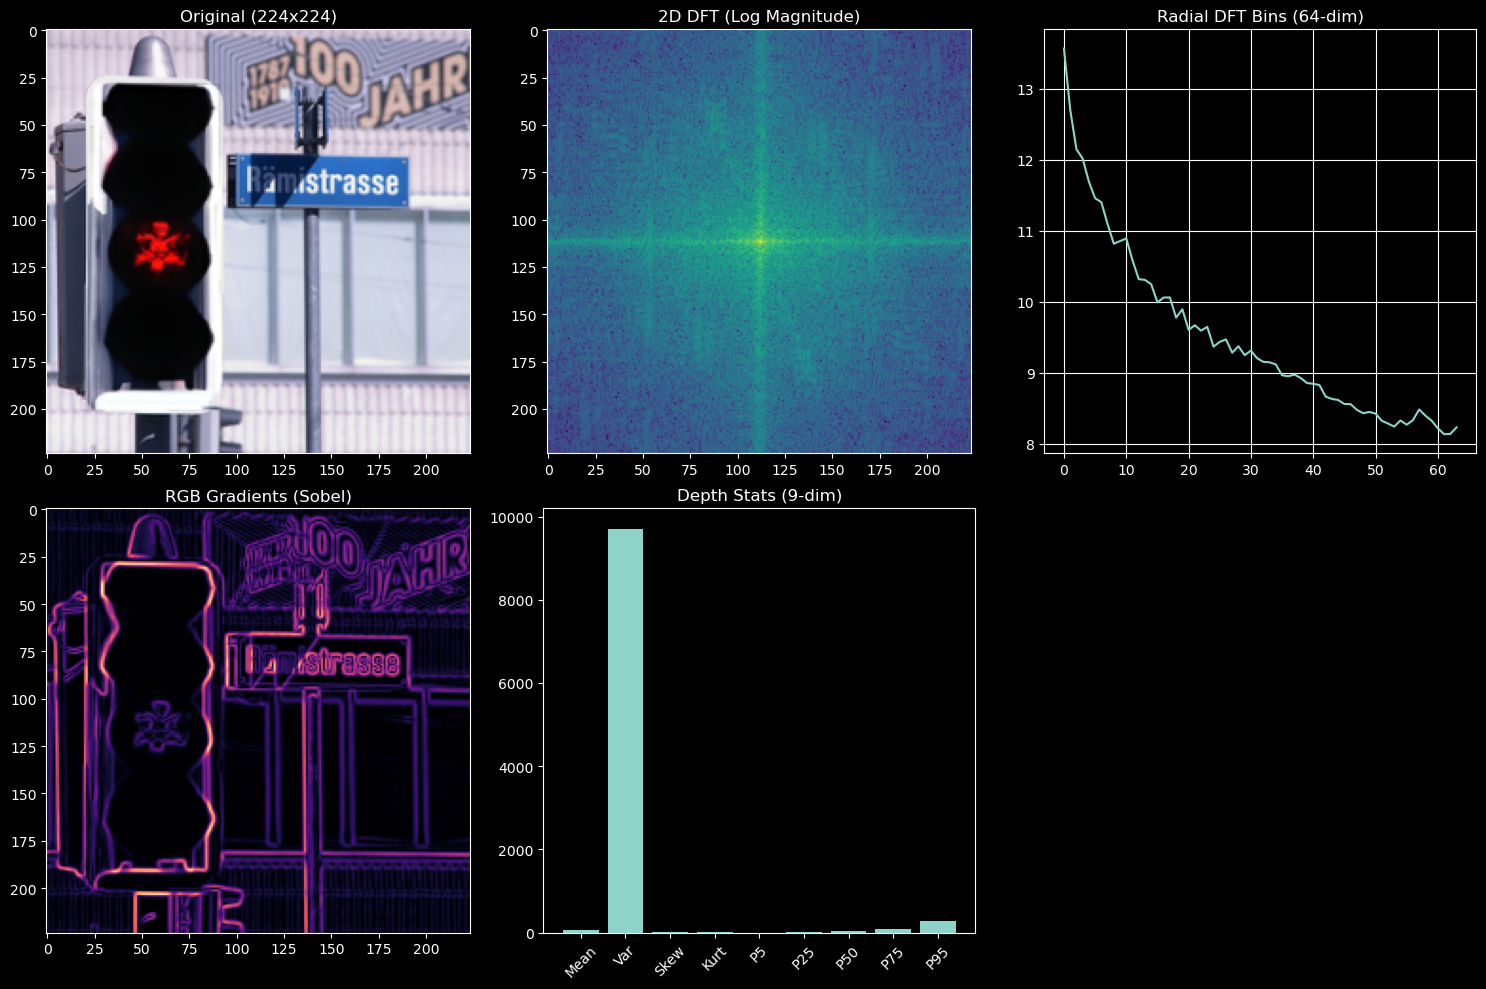

Spectral Vector Shape: (192,) (Expected: 192)
Depth Vector Shape: (9,) (Expected: 9)


In [6]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Make sure the repository root (the folder that contains "src") is importable
project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    for parent in project_root.parents:
        if (parent / "src").exists():
            project_root = parent
            break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

signal_proc = importlib.import_module("src.preprocessing.signal_proc")
extract_spectral_features = signal_proc.extract_spectral_features
extract_depth_features = signal_proc.extract_depth_features


# 1. Load a test image (Pick an AI-generated one for better results)
# img_path = "../data/raw/CoCoGlide/real/traffic light_284762.png"
img_path = "../data/raw/CoCoGlide/fake/glide_inpainting_val2017_284762_up.png"
# img_path = "../data/raw/AutoSplice/Authentic/39406.jpg"
# img_path = "../data/raw/AutoSplice/Forged_JPEG90/39406_2.jpg"
# img_path = "../data/raw/r000da54ft.NEF"
img_bgr = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_rgb = cv2.resize(img_rgb, (224, 224))

# 2. Extract Spectral Features (Stream B)
# We manually redo some math here just for the 2D visualization
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
spectral_vector = extract_spectral_features(img_rgb)

# 3. Create a Dummy Depth Map (For testing Stream C without MiDaS yet)
# In reality, you'd load the MiDaS output here
dummy_depth = cv2.GaussianBlur(gray, (15, 15), 0)
depth_vector = extract_depth_features(img_rgb, dummy_depth)

# 4. PLOTTING
plt.figure(figsize=(15, 10))

# Original Image
plt.subplot(2, 3, 1)
plt.title("Original (224x224)")
plt.imshow(img_rgb)

# 2D Fourier Spectrum
plt.subplot(2, 3, 2)
plt.title("2D DFT (Log Magnitude)")
plt.imshow(magnitude_spectrum, cmap="viridis")

# 1D Radial Bins (The actual 64-dim vector)
plt.subplot(2, 3, 3)
plt.title("Radial DFT Bins (64-dim)")
plt.plot(spectral_vector[128:])  # The DFT part starts after 128 DCT components
plt.grid(True)

# RGB Gradients (Stream C logic)
plt.subplot(2, 3, 4)
plt.title("RGB Gradients (Sobel)")
grad_rgb = np.sqrt(
    cv2.Sobel(gray, cv2.CV_64F, 1, 0) ** 2 + cv2.Sobel(gray, cv2.CV_64F, 0, 1) ** 2
)
plt.imshow(grad_rgb, cmap="magma")

# Depth Stats Visualization
plt.subplot(2, 3, 5)
plt.title("Depth Stats (9-dim)")
plt.bar(range(9), depth_vector)
plt.xticks(
    range(9),
    ["Mean", "Var", "Skew", "Kurt", "P5", "P25", "P50", "P75", "P95"],
    rotation=45,
)

plt.tight_layout()
plt.show()

print(f"Spectral Vector Shape: {spectral_vector.shape} (Expected: 192)")
print(f"Depth Vector Shape: {depth_vector.shape} (Expected: 9)")
